In [ ]:
# Importación de las bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans, DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
import math
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [ ]:
# Generación de los datos
def make_circle(r, n, noise = 30, seed = 1234):
  np.random.seed(seed)
  return [(math.cos(2*math.pi/n*x)*r+np.random.normal(-noise,noise), math.sin(2*math.pi/n*x)*r+np.random.normal(-noise,noise)) for x in range(1,n+1)]

small_circle = make_circle(100, 300, 10)
medium_circle = make_circle(300, 700, 20)
big_circle = make_circle(500, 1000, 30)

noise = [(np.random.randint(-600,600),np.random.randint(-600,600)) for i in range(300)]

<Axes: xlabel='x', ylabel='y'>

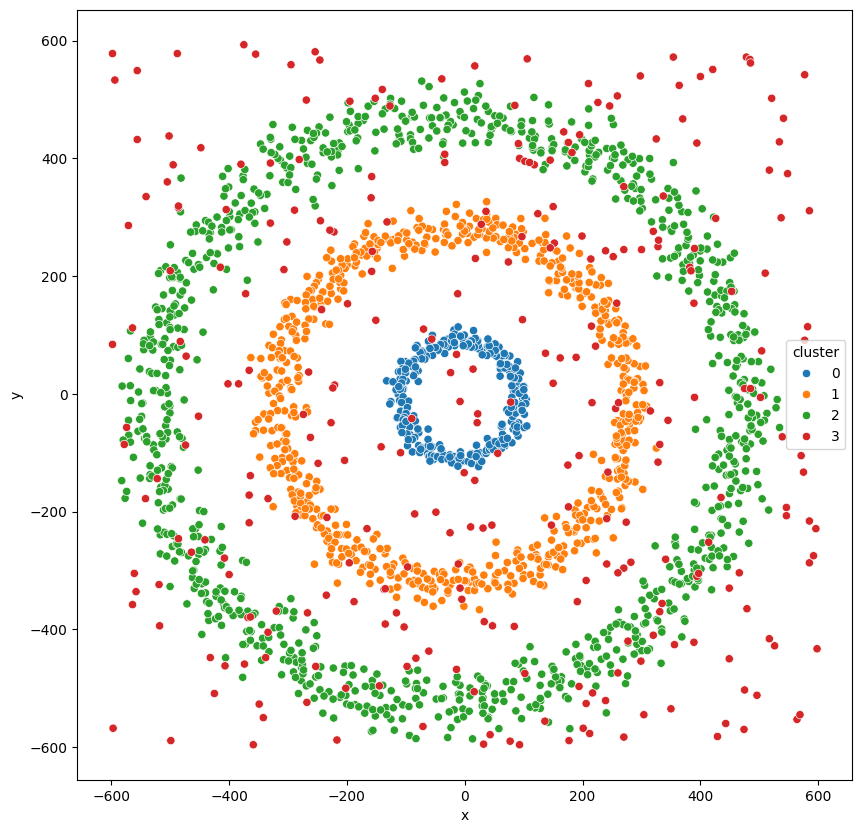

In [ ]:
# Conversión a data frame
"""
Clusteritzar dades segons formes complexes que, a més, compten amb outliers.
"""
def arrray_to_df(arr, i):
  df = pd.DataFrame(arr)
  df['cluster'] = str(i)
  return df

data = [arrray_to_df(arr, i) for i, arr in enumerate([small_circle, medium_circle, big_circle, noise])]

data = pd.concat(data)
data.columns = ['x', 'y', 'cluster']


plt.rcParams['figure.figsize'] = [10,10]
sns.scatterplot(
    data = data,
    x = 'x',
    y = 'y',
    hue = 'cluster'
)

Silhouette Score: 0.4758108343400702


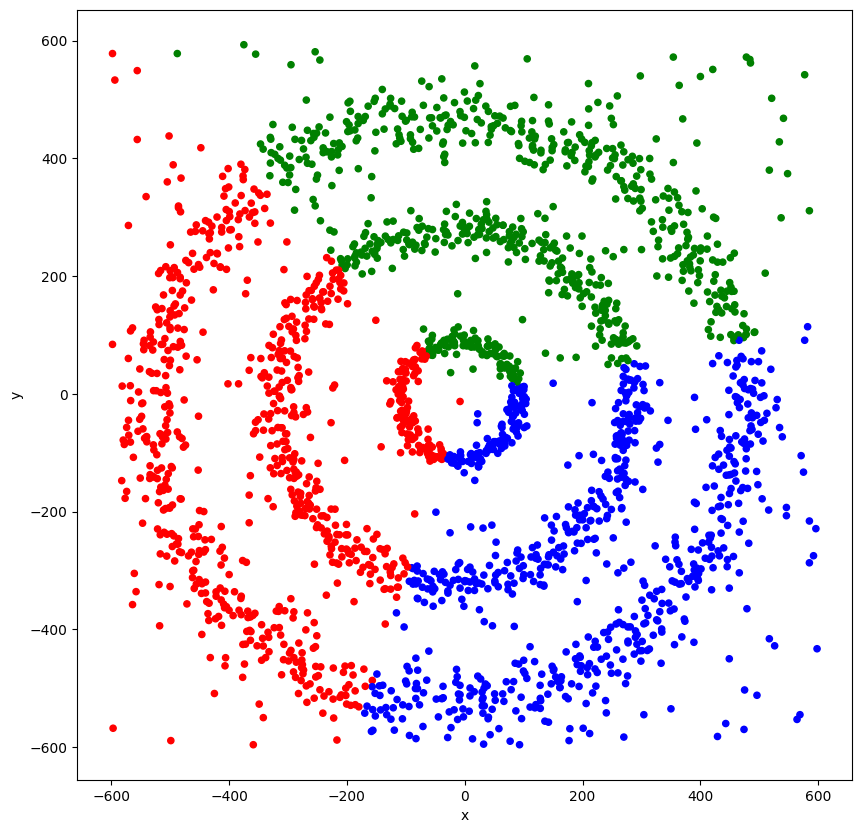

In [ ]:
# K-means
"""
K-means ha realizado una mala agrupación, ya que:

No ha sido capaz de identificar correctamente las formas complejas presentes en los datos.
Tampoco ha tenido en cuenta la presencia de outliers, que han acabado incluidos dentro de los distintos clústeres.
"""
data_norm = normalize(data)

preds = KMeans(n_clusters = 3, random_state =123).fit_predict(data_norm)

cols = {
  0: 'r',
  1: 'g',
  2: 'b'
}

data['kmeans_pred'] = [cols.get(pred) for pred in preds]
data.plot.scatter('x', 'y', c='kmeans_pred')

silhouette_avg = silhouette_score(data_norm, data['kmeans_pred'])
print(f"Silhouette Score: {silhouette_avg}")

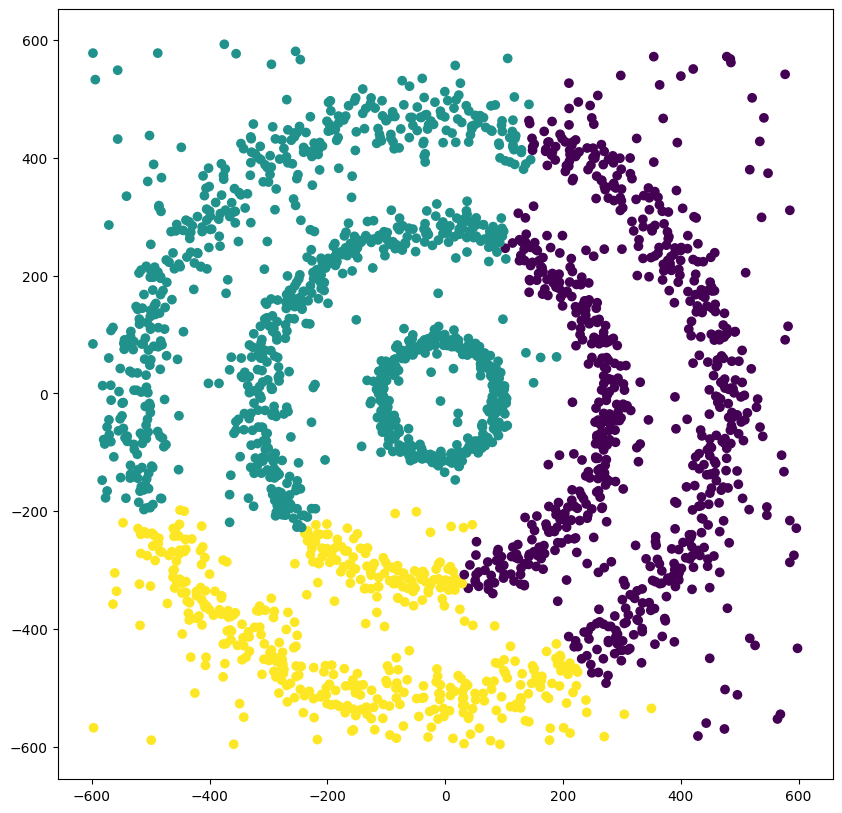

Puntuación de Silhouette: 0.3246006764167603


In [ ]:
# Agglomerative
num_clusters = 3

# Crea una instancia del algoritmo de agrupamiento aglomerativo
agglomerative = AgglomerativeClustering(n_clusters=num_clusters)

# Ajusta el modelo a tus datos
data['agglomerative'] = agglomerative.fit_predict(data[['x', 'y']])

# Visualiza los resultados
plt.scatter(data['x'], data['y'], c=data['agglomerative'])
plt.show()

silhouette_avg = silhouette_score(data[['x', 'y']], data['agglomerative'])
print(f"Puntuación de Silhouette: {silhouette_avg}")

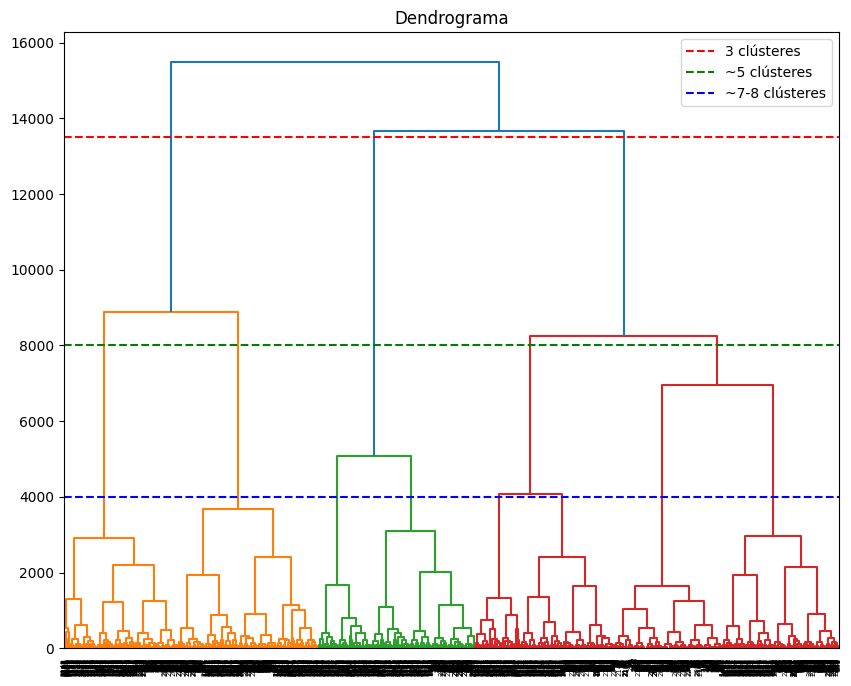

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Suponiendo que 'data' ya contiene las columnas 'x' e 'y'
num_clusters = 3

# Crea una instancia del algoritmo de agrupamiento aglomerativo
agglomerative = AgglomerativeClustering(n_clusters=num_clusters)
data['agglomerative'] = agglomerative.fit_predict(data[['x', 'y']])

# Crea una matriz de enlaces a partir de los datos
linkage_matrix = linkage(data[['x', 'y']], method='ward')

# Visualiza el dendrograma
plt.figure(figsize=(10, 8))
dendrogram(linkage_matrix)
plt.axhline(y=13500, color='r', linestyle='--', label='3 clústeres')
plt.axhline(y=8000, color='g', linestyle='--', label='~5 clústeres')
plt.axhline(y=4000, color='b', linestyle='--', label='~7-8 clústeres')
plt.title('Dendrograma')
plt.legend()
plt.show()

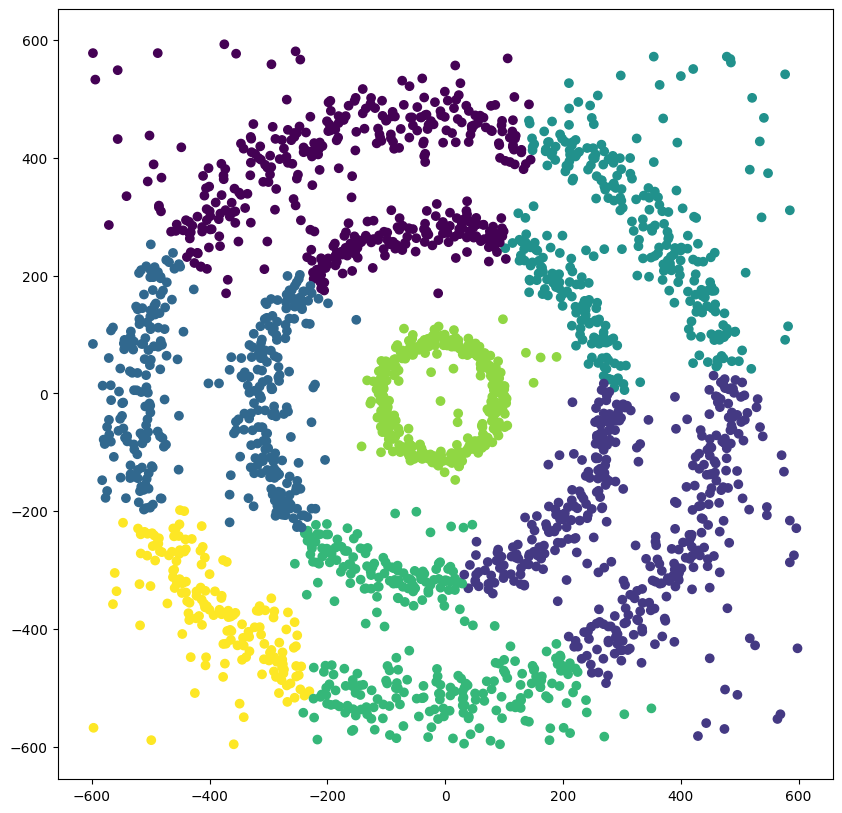

Puntuación de Silhouette: 0.3638800037707364


In [ ]:
# Agglomerative
num_clusters = 7

# Crea una instancia del algoritmo de agrupamiento aglomerativo
agglomerative = AgglomerativeClustering(n_clusters=num_clusters)

# Ajusta el modelo a tus datos
data['agglomerative'] = agglomerative.fit_predict(data[['x', 'y']])

# Visualiza los resultados
plt.scatter(data['x'], data['y'], c=data['agglomerative'])
plt.show()

silhouette_avg = silhouette_score(data[['x', 'y']], data['agglomerative'])
print(f"Puntuación de Silhouette: {silhouette_avg}")


Puntuación de Silhouette: -0.10410912284250745


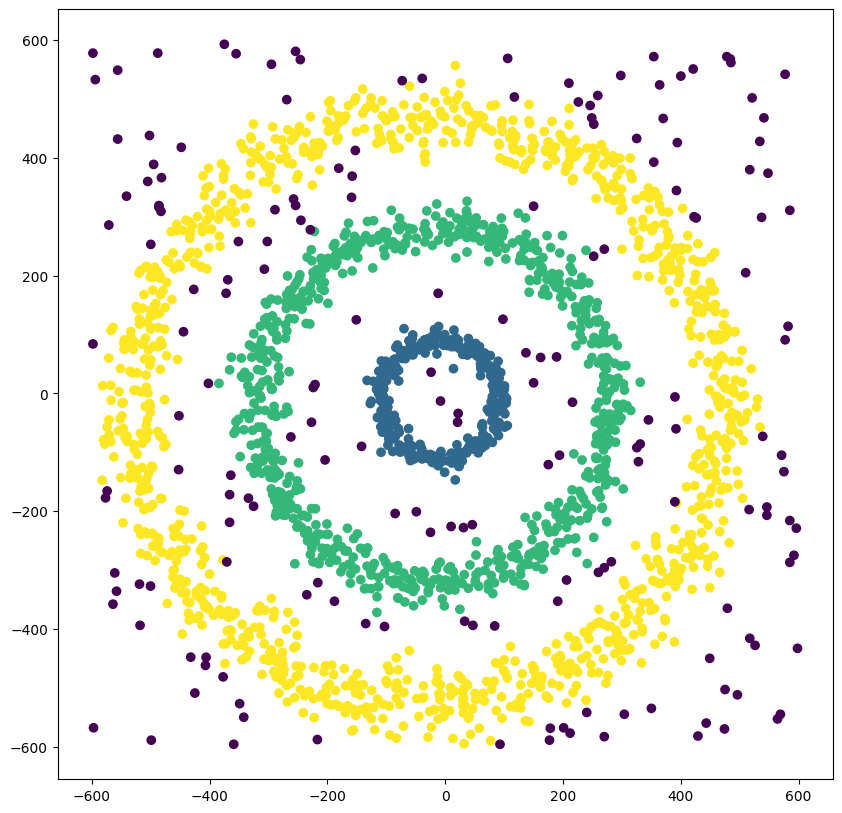

In [ ]:
# DBSCAN
"""
DBSCAN ha logrado agrupar correctamente los datos, ya que:

Ha tenido en cuenta las formas complejas presentes en los datos.
No ha incluido el ruido dentro de ningún clúster.
"""
data['dbscan'] = DBSCAN(eps=32, min_samples=5).fit_predict(data[['x', 'y']])

plt.scatter(
    data['x'],
    data['y'],
    c = data['dbscan']
)

silhouette_avg = silhouette_score(data[['x', 'y']], data['dbscan'])
print(f"Puntuación de Silhouette: {silhouette_avg}")

DBSCAN es un algoritmo basado en densidad que permite identificar clústeres con formas irregulares y tratar los outliers como ruido. No requiere que los clústeres tengan forma esférica, lo que lo hace especialmente adecuado para datos con estructuras complejas. Sin embargo, esta flexibilidad hace que la puntuación de Silhouette pueda no ser tan representativa, ya que esta métrica parte de la suposición de clústeres más bien regulares.

K-means y el agrupamiento aglomerativo, en cambio, asumen que los clústeres son más o menos esféricos y resultan más sensibles a los outliers. En estos casos, la puntuación de Silhouette suele ser más informativa, ya que encaja mejor con la forma que estos algoritmos esperan encontrar.

Por tanto, cuando se trabaja con datos complejos o con ruido, DBSCAN puede ser una opción más adecuada, aunque la puntuación de Silhouette no refleje del todo su buen rendimiento. En cambio, para K-means y Agglomerative, esta métrica suele aportar información más útil gracias a las suposiciones que hacen sobre la forma de los clústeres.